## check ranking

In [1]:
using Distributions, Random, Statistics, MultipleTesting
using Empirikos, Hypatia, LinearAlgebra
using StatsPlots

Random.seed!(105)

# simulation parameters
n_values = [4, 5, 6, 8, 10, 20, 30, 40]
G = 1000
R = 100

p_signal = 0.1
β_signal = 4.0

# variance prior
s0_sq_true = 1.0
d0_true = 4.0

# storage
datasets = Dict{Tuple{Int,Int}, Any}()

function rand_scaled_uniform_errors(
    rng::AbstractRNG,
    n::Int
)
    a = -sqrt(3)
    b = sqrt(3)

    return rand(rng, Uniform(a, b), n)
end

for n in n_values
    for r in 1:R

        rng = MersenneTwister(10_000 + 100n + r)

        is_DE = rand(rng, G) .< p_signal

        σ2 = rand(
            rng,
            InverseGamma(d0_true / 2,
                         d0_true * s0_sq_true / 2),
            G
        )

        σ = sqrt.(σ2)

        Y = Vector{Vector{Float64}}(undef, G)

        @inbounds for i in 1:G

            # βi = is_DE[i] ? β_signal * σ[i] : 0.0
            βi = is_DE[i] ? β_signal * σ[i] / sqrt(n) : 0.0

            z = rand_scaled_uniform_errors(
                rng,
                n
            )

            Y[i] = βi .+ σ[i] .* z
        end


        datasets[(n,r)] = (
            Y = Y,
            is_DE = is_DE,
            σ = σ,
            σ2 = σ2,
            error_dist = "Variance-standardized Uniform",
            β_signal = β_signal,
            s0_sq_true = s0_sq_true,
            d0_true = d0_true
        )

    end
end

In [3]:
# using Distributions, Random, Statistics, MultipleTesting, Empirikos, Hypatia, LinearAlgebra
# using StatsPlots

# # =========================================================
# # Draw from a mixture of Laplace errors
# # baseline: variance 1
# # contamination: variance tau^2
# # =========================================================
# function rand_mixture_laplace_errors(
#     rng::AbstractRNG,
#     n::Int;
#     eps::Float64 = 0.05,
#     tau::Float64 = 8.0
# )
#     b_main = 1 / sqrt(2)           # Var = 1
#     b_out  = tau / sqrt(2)         # Var = tau^2

#     z = Vector{Float64}(undef, n)

#     @inbounds for j in 1:n
#         if rand(rng) < eps
#             z[j] = rand(rng, Laplace(0.0, b_out))
#         else
#             z[j] = rand(rng, Laplace(0.0, b_main))
#         end
#     end

#     return z
# end

# # =========================================================
# # Simulation with mixture-Laplace errors
# # =========================================================
# Random.seed!(105)

# n_values = [4,5,6,8,10,20,30,40]

# G = 1000
# R = 100

# p_signal = 0.1

# # This is now the constant standardized signal
# β_signal = 4.0

# # parametric variance model
# s0_sq_true = 1.0
# d0_true    = 4.0

# # mixture-Laplace parameters
# eps_mix = 0.15
# tau_mix = 9.0

# datasets = Dict{Tuple{Int,Int}, Any}()

# for n in n_values
#     for r in 1:R

#         rng = MersenneTwister(10_000 + 100n + r)

#         is_DE = rand(rng, G) .< p_signal

#         # gene-specific variance
#         σ2 = rand(
#             rng,
#             InverseGamma(
#                 d0_true / 2,
#                 d0_true * s0_sq_true / 2
#             ),
#             G
#         )

#         σ = sqrt.(σ2)

#         # data generation
#         Y = Vector{Vector{Float64}}(undef, G)

#         @inbounds for i in 1:G

#             # IMPORTANT CHANGE:
#             # scale signal by 1/sqrt(n)
#             βi = is_DE[i] ?
#                  β_signal * σ[i] / sqrt(n) :
#                  0.0

#             z = rand_mixture_laplace_errors(
#                 rng,
#                 n;
#                 eps = eps_mix,
#                 tau = tau_mix
#             )

#             Y[i] = βi .+ σ[i] .* z
#         end

#         datasets[(n, r)] = (
#             Y = Y,
#             is_DE = is_DE,
#             σ = σ,
#             σ2 = σ2,
#             error_dist = "Laplace Mixture",
#             eps_mix = eps_mix,
#             tau_mix = tau_mix,
#             β_signal = β_signal,
#             signal_scaled_by_sqrt_n = true,
#             s0_sq_true = s0_sq_true,
#             d0_true = d0_true
#         )
#     end
# end

In [2]:
limma_summary = Dict(
    "n" => Int[],
    "TP" => Float64[],
    "FP" => Float64[],
    "Power" => Float64[],
    "FDR" => Float64[],
    "TP_top100" => Float64[]
)

# Store full per-gene p-values
limma_pvals_store = Dict{Tuple{Int,Int}, Vector{Float64}}()

# Store replicate-level top-100 results
limma_top100_store = Dict{Tuple{Int,Int}, Int}()


# =========================================================
# Loop over sample sizes
# =========================================================
for n in n_values

    println("\n========== Running LIMMA simulation for n = $n ==========")

    ν = n - 1

    power_vals  = Float64[]
    fdr_vals    = Float64[]
    tp_vals     = Float64[]
    fp_vals     = Float64[]
    top100_vals = Float64[]

    for r in 1:R

        try
            Y     = datasets[(n,r)].Y
            is_DE = datasets[(n,r)].is_DE
            σ     = datasets[(n,r)].σ

            # -------------------------------------------------
            # Per-gene statistics
            # -------------------------------------------------
            β_hat = [mean(Y[i]) for i in 1:G]

            s_hat = [
                std(Y[i], corrected=true)
                for i in 1:G
            ]

            se_hat_squared = (s_hat .^ 2) ./ n


            # -------------------------------------------------
            # LIMMA samples
            # -------------------------------------------------
            samples = [
                Empirikos.NormalChiSquareSample(
                    β_hat[i],
                    se_hat_squared[i],
                    ν
                )
                for i in 1:G
            ]


            # -------------------------------------------------
            # Fit LIMMA EB test
            # -------------------------------------------------
            test_limma = Empirikos.EmpiricalPartiallyBayesTTest(
                α = 0.05,
                prior = Empirikos.Limma(),
                solver = Hypatia.Optimizer
            )

            res_limma = fit(test_limma, samples)


            # -------------------------------------------------
            # Extract p-values and rejection decisions
            # -------------------------------------------------
            pvals_limma = res_limma.pvalue
            rej_limma   = res_limma.rj_idx


            # =================================================
            # SAVE THE RAW P-VALUES
            # =================================================
            limma_pvals_store[(n,r)] = copy(pvals_limma)


            # =================================================
            # Standard rejection-based metrics
            # =================================================
            TP = sum(rej_limma .& is_DE)
            FP = sum(rej_limma .& .!is_DE)

            power = TP / max(sum(is_DE), 1)

            fdr = FP / max(sum(rej_limma), 1)


            # =================================================
            # Ranking metric: true signals among top 100
            # =================================================
            k = min(100, G)

            ord = sortperm(pvals_limma)

            top_idx = ord[1:k]

            TP_top100 = sum(is_DE[top_idx])


            # Store replicate-level ranking result
            limma_top100_store[(n,r)] = TP_top100


            # -------------------------------------------------
            # Collect replicate metrics
            # -------------------------------------------------
            push!(tp_vals, TP)
            push!(fp_vals, FP)

            push!(power_vals, power)
            push!(fdr_vals, fdr)

            push!(top100_vals, TP_top100)


        catch err

            @warn "Skipping Rep $r for n=$n due to numerical error: $err"

            continue
        end
    end


    # =========================================================
    # Average over replicates
    # =========================================================
    mean_TP     = mean(tp_vals)
    mean_FP     = mean(fp_vals)

    mean_power  = mean(power_vals)
    mean_fdr    = mean(fdr_vals)

    mean_top100 = mean(top100_vals)


    push!(limma_summary["n"], n)

    push!(limma_summary["TP"], mean_TP)
    push!(limma_summary["FP"], mean_FP)

    push!(limma_summary["Power"], mean_power)
    push!(limma_summary["FDR"], mean_fdr)

    push!(limma_summary["TP_top100"], mean_top100)


    println(
        "n = $n → " *
        "Power=$(round(mean_power, digits=3)) | " *
        "FDR=$(round(mean_fdr, digits=3)) | " *
        "TP=$(round(mean_TP, digits=1)) | " *
        "FP=$(round(mean_FP, digits=1)) | " *
        "TP@100=$(round(mean_top100, digits=1))"
    )
end


# =========================================================
# Final summary
# =========================================================
println("\n========== LIMMA SUMMARY ACROSS SAMPLE SIZES ==========")

for i in eachindex(limma_summary["n"])

    println(
        "n = $(limma_summary["n"][i]) → " *
        "Power=$(round(limma_summary["Power"][i], digits=5)), " *
        "FDR=$(round(limma_summary["FDR"][i], digits=5)), " *
        "TP@100=$(round(limma_summary["TP_top100"][i], digits=3))"
    )
end


========== Running LIMMA simulation for n = 4 ==========
n = 4 → Power=0.389 | FDR=0.105 | TP=38.6 | FP=4.6 | TP@100=77.6

========== Running LIMMA simulation for n = 5 ==========
n = 5 → Power=0.427 | FDR=0.1 | TP=43.0 | FP=4.9 | TP@100=79.2

========== Running LIMMA simulation for n = 6 ==========
n = 6 → Power=0.497 | FDR=0.093 | TP=49.7 | FP=5.3 | TP@100=80.5

========== Running LIMMA simulation for n = 8 ==========
n = 8 → Power=0.57 | FDR=0.083 | TP=57.3 | FP=5.2 | TP@100=82.4

========== Running LIMMA simulation for n = 10 ==========
n = 10 → Power=0.649 | FDR=0.072 | TP=65.4 | FP=5.1 | TP@100=84.5

========== Running LIMMA simulation for n = 20 ==========
n = 20 → Power=0.781 | FDR=0.051 | TP=78.4 | FP=4.3 | TP@100=88.2

========== Running LIMMA simulation for n = 30 ==========
n = 30 → Power=0.811 | FDR=0.056 | TP=80.0 | FP=4.8 | TP@100=87.9

========== Running LIMMA simulation for n = 40 ==========
n = 40 → Power=0.833 | FDR=0.049 | TP=83.0 | FP=4.3 | TP@100=89.1

==========

## NP +SD

In [3]:
R = 100

# =========================================================
# Storage for summary results
# =========================================================
epb_summary = Dict(
    "n" => Int[],
    "TP" => Float64[],
    "FP" => Float64[],
    "Power" => Float64[],
    "FDR" => Float64[],
    "TP_top100" => Float64[]
)

# Store full raw p-values for every successful replicate
epb_pvals_store = Dict{Tuple{Int,Int}, Vector{Float64}}()

# Store replicate-level TP@100
epb_top100_store = Dict{Tuple{Int,Int}, Int}()


# =========================================================
# Loop over sample sizes
# =========================================================
for n in n_values

    println("\n========== Running EPB NPMLE simulation for n = $n ==========")

    ν = n - 1

    power_vals  = Float64[]
    fdr_vals    = Float64[]
    tp_vals     = Float64[]
    fp_vals     = Float64[]
    top100_vals = Float64[]

    for r in 1:R

        try
            # -------------------------------------------------
            # Get the same simulated dataset
            # -------------------------------------------------
            Y     = datasets[(n,r)].Y
            is_DE = datasets[(n,r)].is_DE
            σ     = datasets[(n,r)].σ


            # -------------------------------------------------
            # Compute per-gene statistics
            # -------------------------------------------------
            β_hat = [mean(Y[i]) for i in 1:G]

            s_hat = [
                std(Y[i], corrected=true)
                for i in 1:G
            ]

            se_hat_squared = (s_hat .^ 2) ./ n


            # -------------------------------------------------
            # Build Normal-Chi-square samples
            # -------------------------------------------------
            samples = [
                Empirikos.NormalChiSquareSample(
                    β_hat[i],
                    se_hat_squared[i],
                    ν
                )
                for i in 1:G
            ]


            # -------------------------------------------------
            # Fit EPB with nonparametric NPMLE prior
            # -------------------------------------------------
            test_epb = Empirikos.EmpiricalPartiallyBayesTTest(
                α = 0.05,
                solver = Hypatia.Optimizer
            )

            res_epb = fit(test_epb, samples)


            # -------------------------------------------------
            # Extract p-values and rejection decisions
            # -------------------------------------------------
            pvals_epb = res_epb.pvalue
            rej_epb   = res_epb.rj_idx


            # =================================================
            # SAVE RAW P-VALUES
            # =================================================
            epb_pvals_store[(n,r)] = copy(pvals_epb)


            # =================================================
            # Standard rejection-based metrics
            # =================================================
            TP = sum(rej_epb .& is_DE)
            FP = sum(rej_epb .& .!is_DE)

            power = TP / max(sum(is_DE), 1)

            fdr = FP / max(sum(rej_epb), 1)


            # =================================================
            # Ranking metric: true DE genes among top 100
            # =================================================
            k = min(100, G)

            ord = sortperm(pvals_epb)

            top_idx = ord[1:k]

            TP_top100 = sum(is_DE[top_idx])


            # Store replicate-level TP@100
            epb_top100_store[(n,r)] = TP_top100


            # -------------------------------------------------
            # Collect replicate metrics
            # -------------------------------------------------
            push!(tp_vals, TP)
            push!(fp_vals, FP)

            push!(power_vals, power)
            push!(fdr_vals, fdr)

            push!(top100_vals, TP_top100)


            println(
                "Rep $r → " *
                "Power=$(round(power, digits=3)) | " *
                "FDR=$(round(fdr, digits=3)) | " *
                "Rej=$(sum(rej_epb)) | " *
                "TP@100=$TP_top100"
            )


        catch e

            @warn "Skipping Rep $r for n=$n due to error: $e"

            continue
        end
    end


    # =========================================================
    # Average over successful replicates
    # =========================================================
    mean_TP     = mean(tp_vals)
    mean_FP     = mean(fp_vals)

    mean_power  = mean(power_vals)
    mean_fdr    = mean(fdr_vals)

    mean_top100 = mean(top100_vals)


    push!(epb_summary["n"], n)

    push!(epb_summary["TP"], mean_TP)
    push!(epb_summary["FP"], mean_FP)

    push!(epb_summary["Power"], mean_power)
    push!(epb_summary["FDR"], mean_fdr)

    push!(epb_summary["TP_top100"], mean_top100)


    println(
        "n = $n → " *
        "Power=$(round(mean_power, digits=3)) | " *
        "FDR=$(round(mean_fdr, digits=3)) | " *
        "TP=$(round(mean_TP, digits=1)) | " *
        "FP=$(round(mean_FP, digits=1)) | " *
        "TP@100=$(round(mean_top100, digits=1))"
    )
end


# =========================================================
# Final summary
# =========================================================
println("\n========== EPB SUMMARY ACROSS SAMPLE SIZES ==========")

for i in eachindex(epb_summary["n"])

    println(
        "n = $(epb_summary["n"][i]) → " *
        "TP=$(round(epb_summary["TP"][i], digits=3)), " *
        "FP=$(round(epb_summary["FP"][i], digits=3)), " *
        "Power=$(round(epb_summary["Power"][i], digits=5)), " *
        "FDR=$(round(epb_summary["FDR"][i], digits=5)), " *
        "TP@100=$(round(epb_summary["TP_top100"][i], digits=3))"
    )
end


========== Running EPB NPMLE simulation for n = 4 ==========

 iter        p_obj        d_obj |  abs_gap    x_feas    z_feas |      tau       kap        mu | dir_res     prox  step     alpha
    0   3.2373e-02  -2.9041e+02 | 2.30e+03  1.67e+02  2.49e+00 | 1.00e+00  1.00e+00  1.00e+00 |
    1  -8.9871e-01  -2.9547e+02 | 2.19e+03  1.69e+02  2.52e+00 | 9.36e-01  1.02e+00  9.50e-01 | 3.0e-12  8.7e-02  co-a  5.00e-02
    2  -2.1752e+00  -2.9841e+02 | 2.08e+03  1.70e+02  2.54e+00 | 8.84e-01  1.02e+00  9.03e-01 | 1.9e-12  1.4e-01  co-a  5.00e-02
    3  -5.7605e+00  -3.0280e+02 | 1.87e+03  1.71e+02  2.54e+00 | 7.93e-01  1.02e+00  8.12e-01 | 3.4e-13  4.1e-01  co-a  1.00e-01
    4  -1.1061e+01  -3.0909e+02 | 1.68e+03  1.72e+02  2.55e+00 | 7.11e-01  1.03e+00  7.31e-01 | 1.6e-12  8.0e-02  co-a  1.00e-01
    5  -1.8385e+01  -3.1655e+02 | 1.51e+03  1.72e+02  2.56e+00 | 6.40e-01  1.03e+00  6.58e-01 | 4.3e-12  3.1e-02  co-a  1.00e-01
    6  -2.8401e+01  -3.2650e+02 | 1.36e+03  1.72e+02  2.56e+00 | 5.

Excessive output truncated after 524300 bytes.

   43  -3.5795e+01  -3.8395e+01 | 6.08e+00  1.27e+00  1.47e-02 

In [4]:

# =========================================================
# Final summary
# =========================================================
println("\n========== EPB SUMMARY ACROSS SAMPLE SIZES ==========")

for i in eachindex(epb_summary["n"])

    println(
        "n = $(epb_summary["n"][i]) → " *
        "TP=$(round(epb_summary["TP"][i], digits=3)), " *
        "FP=$(round(epb_summary["FP"][i], digits=3)), " *
        "Power=$(round(epb_summary["Power"][i], digits=5)), " *
        "FDR=$(round(epb_summary["FDR"][i], digits=5)), " *
        "TP@100=$(round(epb_summary["TP_top100"][i], digits=3))"
    )
end


========== EPB SUMMARY ACROSS SAMPLE SIZES ==========
n = 4 → TP=32.737, FP=3.96, Power=0.32762, FDR=0.10353, TP@100=77.687
n = 5 → TP=42.276, FP=4.888, Power=0.42063, FDR=0.1013, TP@100=79.398
n = 6 → TP=49.03, FP=5.394, Power=0.4899, FDR=0.09675, TP@100=80.495
n = 8 → TP=58.212, FP=5.354, Power=0.58028, FDR=0.08509, TP@100=82.616
n = 10 → TP=66.31, FP=5.46, Power=0.65796, FDR=0.07499, TP@100=84.56
n = 20 → TP=78.49, FP=4.43, Power=0.78221, FDR=0.05221, TP@100=88.09
n = 30 → TP=80.29, FP=5.02, Power=0.81372, FDR=0.058, TP@100=87.98
n = 40 → TP=82.899, FP=4.566, Power=0.83136, FDR=0.05183, TP@100=89.04


In [5]:
# R=100
# # --- Storage for summary results ---
# epb_summary = Dict(
#     "n" => Int[],
#     "TP" => Float64[],
#     "FP" => Float64[],
#     "Power" => Float64[],
#     "FDR" => Float64[]
# )

# # --- Loop over sample sizes ---
# for n in n_values
#     println("\n========== Running EPB NPMLE simulation for n = $n ==========")
#     ν = n - 1

#     power_vals = Float64[]
#     fdr_vals   = Float64[]
#     tp_vals    = Float64[]
#     fp_vals    = Float64[]

#     for r in 1:R
#         try
#             # 1️⃣ Simulate true effects and per-gene noise
#             (Y, is_DE, σ) = (datasets[(n,r)].Y, datasets[(n,r)].is_DE, datasets[(n,r)].σ)
#             # is_DE   = rand(G) .< p_signal
#             # σ_true  = σ_support[rand(Categorical(π_true), G)]

#             # # 2️⃣ Simulate data per gene
#             # Y = [rand(Normal(is_DE[i] ? β_signal * σ_true[i] : 0.0, σ_true[i]), n) for i in 1:G]

#             # 3️⃣ Compute statistics
#             β_hat = [mean(Y[i]) for i in 1:G]
#             s_hat = [std(Y[i], corrected=true) for i in 1:G]
#             se_hat_squared = (s_hat .^ 2) ./ n

#             # 4️⃣ Build Normal–Chi-square samples
#             samples = [Empirikos.NormalChiSquareSample(β_hat[i], se_hat_squared[i], ν) for i in 1:G]

#             # 5️⃣ Fit EPB with nonparametric NPMLE prior
#             test_epb = Empirikos.EmpiricalPartiallyBayesTTest(α = 0.05, solver = Hypatia.Optimizer)
#             res_epb  = fit(test_epb, samples)

#             # 6️⃣ Extract results
#             pvals_epb = res_epb.pvalue
#             rej_epb   = res_epb.rj_idx

#             TP  = sum(rej_epb .&  is_DE)
#             FP  = sum(rej_epb .& .!is_DE)
#             power = TP / max(sum(is_DE), 1)
#             fdr   = FP / max(sum(rej_epb), 1)

#             push!(tp_vals, TP)
#             push!(fp_vals, FP)
#             push!(power_vals, power)
#             push!(fdr_vals, fdr)

#             println("Rep $r → Power=$(round(power, digits=3)) | FDR=$(round(fdr, digits=3)) | Rej=$(sum(rej_epb))")

#         catch e
#             println("⚠️  Skipping Rep $r for n=$n due to error: $(typeof(e))")
#             continue
#         end
#     end

#     # --- Summarize results for this n ---
#     mean_TP = mean(tp_vals)
#     mean_FP = mean(fp_vals)
#     mean_power = mean(power_vals)
#     mean_fdr = mean(fdr_vals)

#     push!(epb_summary["n"], n)
#     push!(epb_summary["TP"], mean_TP)
#     push!(epb_summary["FP"], mean_FP)
#     push!(epb_summary["Power"], mean_power)
#     push!(epb_summary["FDR"], mean_fdr)

#     println("n = $n → Power=$(round(mean_power, digits=3)) | FDR=$(round(mean_fdr, digits=3)) | TP=$(round(mean_TP, digits=1)) | FP=$(round(mean_FP, digits=1))")
# end

## MAD P

In [8]:
using FastGaussQuadrature
using Distributions
using StatsFuns: logsumexp
using Optim
using MultipleTesting
using Statistics, Random, LinearAlgebra
using ApproxFun, SpecialFunctions

# =========================================================
# 1. Exact MAD-about-mean likelihood
# =========================================================

struct MADDistribution{T<:Real,S<:Integer} <: ContinuousUnivariateDistribution
    σ::T
    n::S
end

import Distributions: pdf, logpdf, insupport, minimum, maximum

function G_recursive(max_r::Int; a=0.0, b=100)
    d = Interval(a, b)
    G = Vector{Fun}(undef, max_r+1)
    G[1] = Fun(x -> 1.0, d)
    for r in 1:max_r
        integrand = Fun(x -> exp(-(x^2)/(2r*(r+1))), d) * G[r]
        G[r+1] = cumsum(integrand)
    end
    return G
end

const _Gcache = Dict{Int,Vector{Fun}}()
_getG(n) = get!(_Gcache, n) do
    G_recursive(n)
end

function _pdf_sigma1(n::Int, m::Real)
    m < 0 && return zero(float(m))
    z   = n * m / 2
    cst = n^(3/2) / (2^((n+1)/2) * π^((n-1)/2))
    G   = _getG(n)
    s   = 0.0
    @inbounds for k in 1:(n-1)
        s += binomial(n, k) * exp(-(m^2 * n^3) / (8k*(n-k))) * G[k](z) * G[n-k](z)
    end
    return cst * s
end

insupport(::MADDistribution, x::Real) = x ≥ 0
minimum(::MADDistribution) = 0.0
maximum(::MADDistribution) = Inf

pdf(d::MADDistribution, m::Real) =
    m < 0 ? 0.0 : (1 / d.σ) * _pdf_sigma1(d.n, m / d.σ)

function logpdf(d::MADDistribution, m::Real)
    m < 0 && return -Inf
    σ, n = d.σ, d.n
    z    = n * m / (2σ)
    logC = (3/2)*log(n) - ((n+1)/2)*log(2) - ((n-1)/2)*log(π)
    G    = _getG(n)

    logs = Float64[]
    @inbounds for k in 1:(n-1)
        val1 = G[k](z)
        val2 = G[n-k](z)
        if val1 > 0 && val2 > 0
            push!(logs,
                log(binomial(n, k)) -
                (m^2 * n^3) / (8σ^2 * k*(n-k)) +
                log(val1) + log(val2)
            )
        end
    end

    return -log(σ) + logC + (isempty(logs) ? -Inf : logsumexp(logs))
end

# =========================================================
# 2. Parametric prior on sigma^2
# =========================================================

struct InverseScaledChiSquare{T,S} <: ContinuousUnivariateDistribution
    σ²::T
    ν::S
end

function Distributions.InverseGamma(d::InverseScaledChiSquare)
    InverseGamma(d.ν / 2, d.ν * d.σ² / 2)
end

Distributions.pdf(d::InverseScaledChiSquare, x::Real) = pdf(InverseGamma(d), x)
Distributions.logpdf(d::InverseScaledChiSquare, x::Real) = logpdf(InverseGamma(d), x)

prior_sigma2(σ0², ν0) = InverseScaledChiSquare(σ0², ν0)

# =========================================================
# 3. Gauss-Legendre quadrature on (0,1)
# =========================================================

function gausslegendre01(K::Int)
    x, w = gausslegendre(K)   # nodes/weights on [-1,1]
    u = (x .+ 1) ./ 2         # map to (0,1)
    w = w ./ 2
    return u, w
end

# =========================================================
# 4. Marginal likelihood by Gauss-Legendre quadrature
#    transform s2 = u/(1-u), u in (0,1)
# =========================================================
function marginal_mad_logdensity_gl(
    D::Float64,
    n::Int,
    σ0²::Float64,
    ν0::Float64,
    u_nodes::Vector{Float64},
    u_weights::Vector{Float64}
)
    prior = prior_sigma2(σ0², ν0)

    logvals = similar(u_nodes)
    @inbounds for j in eachindex(u_nodes)
        u = clamp(u_nodes[j], 1e-12, 1 - 1e-12)
        s2 = u / (1 - u)
        jac = 1 / (1 - u)^2

        logvals[j] =
            logpdf(MADDistribution(sqrt(s2), n), D) +
            logpdf(prior, s2) +
            log(jac) +
            log(u_weights[j])
    end

    return logsumexp(logvals)
end

# =========================================================
# 5. Negative log marginal likelihood across genes
# =========================================================

function negloglik_mad_parametric_gl(
    par::Vector{Float64},
    mad_obs::Vector{Float64},
    n::Int,
    u_nodes::Vector{Float64},
    u_weights::Vector{Float64}
)
    η, ξ = par
    σ0² = exp(η)
    ν0  = exp(ξ)

    total = 0.0
    @inbounds for D in mad_obs
        total -= marginal_mad_logdensity_gl(D, n, σ0², ν0, u_nodes, u_weights)
    end
    return total
end

# =========================================================
# 6. Fit prior hyperparameters by Gaussian quadrature
# =========================================================

function fit_mad_parametric_prior_gl(
    mad_obs::Vector{Float64},
    n::Int;
    K_quad::Int = 64,
    init_logσ0² = log(max(median(mad_obs)^2, 1e-6)),
    init_logν0  = log(10.0),
    max_iter::Int = 80
)
    u_nodes, u_weights = gausslegendre01(K_quad)

    obj(par) = negloglik_mad_parametric_gl(par, mad_obs, n, u_nodes, u_weights)

    res = optimize(
        obj,
        [init_logσ0², init_logν0],
        NelderMead(),
        Optim.Options(iterations=max_iter, show_trace=false)
    )

    ηhat, ξhat = Optim.minimizer(res)

    return (
        σ0² = exp(ηhat),
        ν0  = exp(ξhat),
        optim = res,
        u_nodes = u_nodes,
        u_weights = u_weights
    )
end

# =========================================================
# 7. Posterior weights on same quadrature nodes
# =========================================================

function posterior_sigma2_weights_mad_gl(
    D::Float64,
    n::Int,
    σ0²::Float64,
    ν0::Float64,
    u_nodes::Vector{Float64},
    u_weights::Vector{Float64}
)
    prior = prior_sigma2(σ0², ν0)

    logpost = similar(u_nodes)
    s2_nodes = similar(u_nodes)

    @inbounds for j in eachindex(u_nodes)
        u = clamp(u_nodes[j], 1e-12, 1 - 1e-12)
        s2 = u / (1 - u)
        s2_nodes[j] = s2
        jac = 1 / (1 - u)^2

        logpost[j] =
            logpdf(MADDistribution(sqrt(s2), n), D) +
            logpdf(prior, s2) +
            log(jac) +
            log(u_weights[j])
    end

    m = maximum(logpost)
    w = exp.(logpost .- m)
    w ./= sum(w)

    return s2_nodes, w
end

# =========================================================
# 8. Posterior-averaged p-value
# =========================================================

function mad_parametric_pvalue_gl(
    β_tilde::Float64,
    D::Float64,
    n::Int,
    σ0²::Float64,
    ν0::Float64,
    u_nodes::Vector{Float64},
    u_weights::Vector{Float64}
)
    s2_nodes, w = posterior_sigma2_weights_mad_gl(D, n, σ0², ν0, u_nodes, u_weights)
    σ_nodes = sqrt.(s2_nodes)
    tails = 2 .* ccdf.(Normal.(0, σ_nodes), abs(β_tilde))
    return dot(tails, w)
end


mad_parametric_pvalue_gl (generic function with 1 method)

In [7]:
# # =========================================================
# # 9. Simulation loop: MAD_mean + parametric prior (Gauss-Legendre)
# #    store both summary means and per-replicate prior fits
# # =========================================================

# mad_param_gl_summary = Dict(
#     "n" => Int[],
#     "TP" => Float64[],
#     "FP" => Float64[],
#     "Power" => Float64[],
#     "FDR" => Float64[]
# )

# mad_param_gl_prior_summary = Dict(
#     "n" => Int[],
#     "sigma0_sq_mean" => Float64[],
#     "nu0_mean" => Float64[]
# )

# # NEW: store replicate-level results
# mad_param_gl_prior_reps = Dict(
#     "n" => Int[],
#     "rep" => Int[],
#     "sigma0_sq_hat" => Float64[],
#     "nu0_hat" => Float64[],
#     "TP" => Float64[],
#     "FP" => Float64[],
#     "Power" => Float64[],
#     "FDR" => Float64[]
# )

# for n in n_values
#     println("\n========== Running MAD_mean + parametric prior (Gauss-Legendre) for n = $n ==========")

#     tp_vals = Float64[]
#     fp_vals = Float64[]
#     power_vals = Float64[]
#     fdr_vals = Float64[]

#     sigma0_sq_vals = Float64[]
#     nu0_vals = Float64[]

#     for r in 1:R
#         try
#             println("n=$n, rep=$r: loading data...")
#             (Y, is_DE, σ_true) = (datasets[(n,r)].Y, datasets[(n,r)].is_DE, datasets[(n,r)].σ)

#             println("n=$n, rep=$r: computing statistics...")
#             β_hat   = [mean(Y[i]) for i in 1:G]
#             mad_obs = [mean(abs.(Y[i] .- β_hat[i])) for i in 1:G]
#             β_tilde = sqrt(n) .* β_hat

#             idx_fit = 1:length(mad_obs)

#             println("n=$n, rep=$r: fitting Gauss-Legendre parametric prior...")
#             @time fit_prior = fit_mad_parametric_prior_gl(
#                 mad_obs[idx_fit], n;
#                 K_quad = 100,
#                 max_iter = 80
#             )

#             σ0²_hat = fit_prior.σ0²
#             ν0_hat  = fit_prior.ν0
#             u_nodes = fit_prior.u_nodes
#             u_weights = fit_prior.u_weights

#             push!(sigma0_sq_vals, σ0²_hat)
#             push!(nu0_vals, ν0_hat)

#             println("n=$n, rep=$r: prior fit done. σ0²=$(round(σ0²_hat, digits=4)), ν0=$(round(ν0_hat, digits=3))")

#             println("n=$n, rep=$r: computing p-values...")
#             pvals = [
#                 mad_parametric_pvalue_gl(β_tilde[i], mad_obs[i], n, σ0²_hat, ν0_hat, u_nodes, u_weights)
#                 for i in 1:G
#             ]

#             adj_p = adjust(pvals, BenjaminiHochberg())
#             rej = adj_p .<= 0.05

#             TP = sum(rej .& is_DE)
#             FP = sum(rej .& .!is_DE)
#             power = TP / max(sum(is_DE), 1)
#             fdr   = FP / max(sum(rej), 1)

#             push!(tp_vals, TP)
#             push!(fp_vals, FP)
#             push!(power_vals, power)
#             push!(fdr_vals, fdr)

#             # NEW: store this replicate's prior + performance
#             push!(mad_param_gl_prior_reps["n"], n)
#             push!(mad_param_gl_prior_reps["rep"], r)
#             push!(mad_param_gl_prior_reps["sigma0_sq_hat"], σ0²_hat)
#             push!(mad_param_gl_prior_reps["nu0_hat"], ν0_hat)
#             push!(mad_param_gl_prior_reps["TP"], TP)
#             push!(mad_param_gl_prior_reps["FP"], FP)
#             push!(mad_param_gl_prior_reps["Power"], power)
#             push!(mad_param_gl_prior_reps["FDR"], fdr)

#             println("n=$n, rep=$r done → Power=$(round(power, digits=3)) | FDR=$(round(fdr, digits=3))")

#         catch e
#             println("⚠️ Skipping Rep $r for n=$n due to error: $(typeof(e)) : $e")
#             continue
#         end
#     end

#     if !isempty(tp_vals)
#         mean_TP = mean(tp_vals)
#         mean_FP = mean(fp_vals)
#         mean_power = mean(power_vals)
#         mean_fdr = mean(fdr_vals)

#         push!(mad_param_gl_summary["n"], n)
#         push!(mad_param_gl_summary["TP"], mean_TP)
#         push!(mad_param_gl_summary["FP"], mean_FP)
#         push!(mad_param_gl_summary["Power"], mean_power)
#         push!(mad_param_gl_summary["FDR"], mean_fdr)

#         push!(mad_param_gl_prior_summary["n"], n)
#         push!(mad_param_gl_prior_summary["sigma0_sq_mean"], mean(sigma0_sq_vals))
#         push!(mad_param_gl_prior_summary["nu0_mean"], mean(nu0_vals))

#         println("✅ Done n=$n → Power=$(round(mean_power, digits=3)) | FDR=$(round(mean_fdr, digits=3)) | TP=$(round(mean_TP, digits=1)) | FP=$(round(mean_FP, digits=1))")
#     else
#         println("⚠️ No successful reps for n=$n")
#     end
# end

In [9]:
# =========================================================
# 9. Simulation loop: MAD_mean + parametric prior
# =========================================================

mad_param_gl_summary = Dict(
    "n" => Int[],
    "TP" => Float64[],
    "FP" => Float64[],
    "Power" => Float64[],
    "FDR" => Float64[],
    "TP_top100" => Float64[]
)

mad_param_gl_prior_summary = Dict(
    "n" => Int[],
    "sigma0_sq_mean" => Float64[],
    "nu0_mean" => Float64[]
)

# Store replicate-level results
mad_param_gl_prior_reps = Dict(
    "n" => Int[],
    "rep" => Int[],
    "sigma0_sq_hat" => Float64[],
    "nu0_hat" => Float64[],
    "TP" => Float64[],
    "FP" => Float64[],
    "Power" => Float64[],
    "FDR" => Float64[],
    "TP_top100" => Float64[]
)

# NEW: store all raw p-values
mad_param_pvals_store =
    Dict{Tuple{Int,Int}, Vector{Float64}}()

# NEW: store replicate-level TP@100
mad_param_top100_store =
    Dict{Tuple{Int,Int}, Int}()


for n in n_values

    println(
        "\n========== Running MAD_mean + parametric prior " *
        "(Gauss-Legendre) for n = $n =========="
    )

    tp_vals = Float64[]
    fp_vals = Float64[]
    power_vals = Float64[]
    fdr_vals = Float64[]
    top100_vals = Float64[]

    sigma0_sq_vals = Float64[]
    nu0_vals = Float64[]


    for r in 1:R

        try
            println("n=$n, rep=$r: loading data...")

            Y = datasets[(n,r)].Y
            is_DE = datasets[(n,r)].is_DE
            σ_true = datasets[(n,r)].σ


            # =================================================
            # Compute statistics
            # =================================================
            println("n=$n, rep=$r: computing statistics...")

            β_hat = [
                mean(Y[i])
                for i in 1:G
            ]

            mad_obs = [
                mean(abs.(Y[i] .- β_hat[i]))
                for i in 1:G
            ]

            β_tilde = sqrt(n) .* β_hat

            idx_fit = 1:length(mad_obs)


            # =================================================
            # Fit parametric MAD prior
            # =================================================
            println(
                "n=$n, rep=$r: fitting Gauss-Legendre parametric prior..."
            )

            @time fit_prior =
                fit_mad_parametric_prior_gl(
                    mad_obs[idx_fit],
                    n;
                    K_quad = 100,
                    max_iter = 80
                )

            σ0²_hat = fit_prior.σ0²
            ν0_hat  = fit_prior.ν0

            u_nodes   = fit_prior.u_nodes
            u_weights = fit_prior.u_weights


            push!(sigma0_sq_vals, σ0²_hat)
            push!(nu0_vals, ν0_hat)


            println(
                "n=$n, rep=$r: prior fit done. " *
                "σ0²=$(round(σ0²_hat, digits=4)), " *
                "ν0=$(round(ν0_hat, digits=3))"
            )


            # =================================================
            # Compute RAW p-values
            # =================================================
            println("n=$n, rep=$r: computing p-values...")

            pvals = [
                mad_parametric_pvalue_gl(
                    β_tilde[i],
                    mad_obs[i],
                    n,
                    σ0²_hat,
                    ν0_hat,
                    u_nodes,
                    u_weights
                )
                for i in 1:G
            ]


            # =================================================
            # NEW: store raw p-values
            # =================================================
            mad_param_pvals_store[(n,r)] = copy(pvals)


            # =================================================
            # NEW: ranking metric TP@100
            # =================================================
            k = min(100, G)

            ord = sortperm(pvals)

            top_idx = ord[1:k]

            TP_top100 = sum(is_DE[top_idx])

            mad_param_top100_store[(n,r)] =
                TP_top100


            # =================================================
            # BH rejection
            # =================================================
            adj_p = adjust(
                pvals,
                BenjaminiHochberg()
            )

            rej = adj_p .<= 0.05


            # =================================================
            # Standard metrics
            # =================================================
            TP = sum(rej .& is_DE)
            FP = sum(rej .& .!is_DE)

            power =
                TP / max(sum(is_DE), 1)

            fdr =
                FP / max(sum(rej), 1)


            push!(tp_vals, TP)
            push!(fp_vals, FP)

            push!(power_vals, power)
            push!(fdr_vals, fdr)

            push!(top100_vals, TP_top100)


            # =================================================
            # Store replicate-level prior + performance
            # =================================================
            push!(mad_param_gl_prior_reps["n"], n)
            push!(mad_param_gl_prior_reps["rep"], r)

            push!(
                mad_param_gl_prior_reps["sigma0_sq_hat"],
                σ0²_hat
            )

            push!(
                mad_param_gl_prior_reps["nu0_hat"],
                ν0_hat
            )

            push!(mad_param_gl_prior_reps["TP"], TP)
            push!(mad_param_gl_prior_reps["FP"], FP)

            push!(
                mad_param_gl_prior_reps["Power"],
                power
            )

            push!(
                mad_param_gl_prior_reps["FDR"],
                fdr
            )

            push!(
                mad_param_gl_prior_reps["TP_top100"],
                TP_top100
            )


            println(
                "n=$n, rep=$r done → " *
                "Power=$(round(power, digits=3)) | " *
                "FDR=$(round(fdr, digits=3)) | " *
                "TP@100=$TP_top100"
            )


        catch e

            println(
                "⚠️ Skipping Rep $r for n=$n due to error: " *
                "$(typeof(e)) : $e"
            )

            continue
        end
    end


    # =========================================================
    # Summarize over successful replicates
    # =========================================================
    if !isempty(tp_vals)

        mean_TP = mean(tp_vals)
        mean_FP = mean(fp_vals)

        mean_power = mean(power_vals)
        mean_fdr = mean(fdr_vals)

        mean_top100 = mean(top100_vals)


        push!(mad_param_gl_summary["n"], n)

        push!(
            mad_param_gl_summary["TP"],
            mean_TP
        )

        push!(
            mad_param_gl_summary["FP"],
            mean_FP
        )

        push!(
            mad_param_gl_summary["Power"],
            mean_power
        )

        push!(
            mad_param_gl_summary["FDR"],
            mean_fdr
        )

        push!(
            mad_param_gl_summary["TP_top100"],
            mean_top100
        )


        # Prior summary
        push!(
            mad_param_gl_prior_summary["n"],
            n
        )

        push!(
            mad_param_gl_prior_summary["sigma0_sq_mean"],
            mean(sigma0_sq_vals)
        )

        push!(
            mad_param_gl_prior_summary["nu0_mean"],
            mean(nu0_vals)
        )


        println(
            "✅ Done n=$n → " *
            "Power=$(round(mean_power, digits=3)) | " *
            "FDR=$(round(mean_fdr, digits=3)) | " *
            "TP=$(round(mean_TP, digits=1)) | " *
            "FP=$(round(mean_FP, digits=1)) | " *
            "TP@100=$(round(mean_top100, digits=1))"
        )

    else

        println("⚠️ No successful reps for n=$n")

    end
end


========== Running MAD_mean + parametric prior (Gauss-Legendre) for n = 4 ==========
n=4, rep=1: loading data...
n=4, rep=1: computing statistics...
n=4, rep=1: fitting Gauss-Legendre parametric prior...
  9.885128 seconds (246.06 M allocations: 4.606 GiB, 3.02% gc time, 6.94% compilation time)
n=4, rep=1: prior fit done. σ0²=1.2311, ν0=4.594
n=4, rep=1: computing p-values...
n=4, rep=1 done → Power=0.373 | FDR=0.073 | TP@100=79
n=4, rep=2: loading data...
n=4, rep=2: computing statistics...
n=4, rep=2: fitting Gauss-Legendre parametric prior...
  8.549943 seconds (228.14 M allocations: 4.167 GiB, 1.99% gc time)
n=4, rep=2: prior fit done. σ0²=1.1937, ν0=4.776
n=4, rep=2: computing p-values...
n=4, rep=2 done → Power=0.247 | FDR=0.08 | TP@100=73
n=4, rep=3: loading data...
n=4, rep=3: computing statistics...
n=4, rep=3: fitting Gauss-Legendre parametric prior...
  9.297056 seconds (242.59 M allocations: 4.431 GiB, 2.28% gc time)
n=4, rep=3: prior fit done. σ0²=1.2407, ν0=5.53
n=4, rep

In [18]:
mad_param_gl_prior_summary

Dict{String, Vector} with 3 entries:
  "sigma0_sq_mean" => [1.17757, 1.31108, 1.46904, 1.7392, 1.95597, 2.65593, 3.0…
  "nu0_mean"       => [1.12326, 1.1584, 1.20799, 1.30435, 1.39848, 1.83332, 2.1…
  "n"              => [4, 5, 6, 8, 10, 20, 30, 40]

In [10]:
# =========================================================
# Final summary
# =========================================================
println(
    "\n========== MAD NP SUMMARY ACROSS SAMPLE SIZES =========="
)

for i in eachindex(mad_param_gl_prior_summary["n"])

    println(
        "n = $(mad_param_gl_summary["n"][i]) → " *
        "TP=$(round(mad_param_gl_summary["TP"][i], digits=3)), " *
        "FP=$(round(mad_param_gl_summary["FP"][i], digits=3)), " *
        "Power=$(round(mad_param_gl_summary["Power"][i], digits=5)), " *
        "FDR=$(round(mad_param_gl_summary["FDR"][i], digits=5)), " *
        "TP@100=$(round(mad_param_gl_summary["TP_top100"][i], digits=3))"
    )
end


========== MAD NP SUMMARY ACROSS SAMPLE SIZES ==========
n = 4 → TP=29.04, FP=3.27, Power=0.29151, FDR=0.10244, TP@100=77.15
n = 5 → TP=34.34, FP=3.58, Power=0.34073, FDR=0.09286, TP@100=78.56
n = 6 → TP=39.4, FP=3.97, Power=0.39292, FDR=0.08868, TP@100=79.27
n = 8 → TP=45.94, FP=3.71, Power=0.45586, FDR=0.07556, TP@100=81.24
n = 10 → TP=52.72, FP=3.72, Power=0.52259, FDR=0.06476, TP@100=83.17
n = 20 → TP=66.75, FP=3.1, Power=0.66362, FDR=0.0428, TP@100=87.12
n = 30 → TP=70.11, FP=2.84, Power=0.70946, FDR=0.03804, TP@100=87.16
n = 40 → TP=73.01, FP=2.55, Power=0.73217, FDR=0.03328, TP@100=88.5


## MAD Np

In [5]:

using Distributions, ApproxFun, SpecialFunctions, QuadGK

# ---- distribution type ----
struct MADDistribution{T<:Real,S<:Integer} <: ContinuousUnivariateDistribution
    σ::T
    n::S
end

# ---- import functions we will EXTEND from Distributions ----
import Distributions: pdf, logpdf, insupport, minimum, maximum

# ---- your helpers (unchanged) ----
function G_recursive(max_r::Int; a=0.0, b=100)
    d = Interval(a, b)
    G = Vector{Fun}(undef, max_r+1)
    G[1] = Fun(x -> 1.0, d)
    for r in 1:max_r
        integrand = Fun(x -> exp(-(x^2)/(2r*(r+1))), d) * G[r]
        G[r+1] = cumsum(integrand)
    end
    return G
end

const _Gcache = Dict{Int,Vector{Fun}}()
_getG(n) = get!(_Gcache, n) do; G_recursive(n) end

function _pdf_sigma1(n::Int, m::Real)
    m < 0 && return zero(float(m))          # support m ≥ 0
    z   = n*m/2
    cst = n^(3/2) / (2^((n+1)/2) * π^((n-1)/2))
    G   = _getG(n)
    s   = 0.0
    @inbounds for k in 1:(n-1)
        s += binomial(n,k) * exp(-(m^2 * n^3)/(8k*(n-k))) * G[k](z) * G[n-k](z)
    end
    return cst*s
end

# ---- extend Distributions API ----
# support (MAD ≥ 0)
insupport(::MADDistribution, x::Real) = x ≥ 0
minimum(::MADDistribution) = 0.0
maximum(::MADDistribution) = Inf

# pdf / logpdf (general σ via scaling)
pdf(d::MADDistribution, m::Real) =
    m < 0 ? 0.0 : (1 / d.σ) * _pdf_sigma1(d.n, m / d.σ)

# logpdf(d::MADDistribution, m::Real) =
#     m < 0 ? -Inf : log(pdf(d, m))


# optional convenience
Base.:*(d::MADDistribution, s::Real) = MADDistribution(d.σ * s, d.n)
Base.:*(s::Real, d::MADDistribution) = d * s

using StatsFuns: logsumexp  # you may need to `Pkg.add("StatsFuns")`

function logpdf(d::MADDistribution, m::Real)
    m < 0 && return -Inf
    σ, n = d.σ, d.n

    # Constants
    z   = n * m / (2σ)
    logC = (3/2)*log(n) - ((n+1)/2)*log(2) - ((n-1)/2)*log(π)
    G = _getG(n)

    # Compute all log-terms (inside the sum)
    logs = Float64[]
    for k in 1:(n-1)
        val1 = G[k](z)
        val2 = G[n-k](z)
        if val1 > 0 && val2 > 0
            logterm = log(binomial(n,k)) -
                      (m^2 * n^3)/(8σ^2 * k*(n-k)) +
                      log(val1) + log(val2)
            push!(logs, logterm)
        end
    end

    # Combine safely
    logsum = isempty(logs) ? -Inf : logsumexp(logs)
    return -log(σ) + logC + logsum
end

using Empirikos, Distributions

# 1) evidence type — must subtype EBayesSample
struct MADSample{T,S} <: Empirikos.EBayesSample{T}
    Z::T   # observed MAD
    n::S   # sample size
end

# 2) likelihood at a given σ (must return a Distributions.jl object)
Empirikos.likelihood_distribution(Z::MADSample, σ) = MADDistribution(σ, Z.n)
# Ensure MADDistribution(σ, n) implements pdf/logpdf

# 3) components() for convex prior machinery (vector of likelihoods over σ-support)
Empirikos.components(convexclass::Empirikos.DiscretePriorClass, Z::MADSample) =
    Empirikos.likelihood_distribution.(Ref(Z), Empirikos.support(convexclass))



# limma-style p-value averaged over the posterior on σ
function Empirikos.limma_pvalue(β̂, Z::MADSample, prior::Empirikos.DiscreteNonParametric)
    post = Empirikos.posterior(Z, prior)
    # println("finish post: ")
    # print(post)

    # println(post)
    σs   = Empirikos.support(post)
    # println("finish σs")
    πs   = Empirikos.probs(post)
    # println("finish πs")
    tails = 2 .* ccdf.(Normal.(0, σs), abs(β̂))
    # println("finish tails")
    dot(tails, πs)
    # println("finish dot")
end

In [6]:
# =========================================================
# Storage for summary results
# =========================================================
mad_summary = Dict(
    "n" => Int[],
    "TP" => Float64[],
    "FP" => Float64[],
    "Power" => Float64[],
    "FDR" => Float64[],
    "TP_top100" => Float64[]
)

# Store full raw p-values for every successful replicate
mad_pvals_store = Dict{Tuple{Int,Int}, Vector{Float64}}()

# Store replicate-level TP@100
mad_top100_store = Dict{Tuple{Int,Int}, Int}()


# =========================================================
# Loop over sample sizes
# =========================================================
for n in n_values

    println("\n========== Running MAD (NP) simulation for n = $n ==========")

    tp_vals     = Float64[]
    fp_vals     = Float64[]
    power_vals  = Float64[]
    fdr_vals    = Float64[]
    top100_vals = Float64[]


    for r in 1:R

        try
            # -------------------------------------------------
            # Get simulated dataset
            # -------------------------------------------------
            Y     = datasets[(n,r)].Y
            is_DE = datasets[(n,r)].is_DE
            σ     = datasets[(n,r)].σ


            # -------------------------------------------------
            # Compute statistics
            # -------------------------------------------------
            β_hat = [
                mean(Y[i])
                for i in 1:G
            ]

            mad_obs = [
                mean(abs.(Y[i] .- β_hat[i]))
                for i in 1:G
            ]

            β_tilde = sqrt(n) .* β_hat


            # -------------------------------------------------
            # Fit NPMLE prior from MAD samples
            # -------------------------------------------------
            Zs_mad = [
                MADSample(mad_obs[i], n)
                for i in 1:G
            ]


            # Grid based on observed MAD values
            σ_grid_raw = sort(unique(mad_obs))

            n_grid = 200

            σ_grid = quantile(
                σ_grid_raw,
                range(0, 1; length=n_grid)
            )

            prior_class =
                Empirikos.DiscretePriorClass(σ_grid)

            npmle = Empirikos.NPMLE(
                prior_class,
                Hypatia.Optimizer
            )

            fitres = Empirikos.fit(
                npmle,
                Zs_mad
            )

            prior_hat =
                Empirikos.clean(fitres.prior)


            # -------------------------------------------------
            # Compute RAW MAD p-values
            # -------------------------------------------------
            pvals = [
                Empirikos.limma_pvalue(
                    β_tilde[i],
                    Zs_mad[i],
                    prior_hat
                )
                for i in 1:G
            ]


            # =================================================
            # SAVE RAW P-VALUES
            # =================================================
            mad_pvals_store[(n,r)] = copy(pvals)


            # -------------------------------------------------
            # BH adjustment for rejection-based analysis
            # -------------------------------------------------
            adj_p = adjust(
                pvals,
                BenjaminiHochberg()
            )

            rej = adj_p .<= 0.05


            # =================================================
            # Standard rejection-based metrics
            # =================================================
            TP = sum(rej .& is_DE)
            FP = sum(rej .& .!is_DE)

            power =
                TP / max(sum(is_DE), 1)

            fdr =
                FP / max(sum(rej), 1)


            # =================================================
            # Ranking metric:
            # true DE genes among 100 smallest RAW p-values
            # =================================================
            k = min(100, G)

            ord = sortperm(pvals)

            top_idx = ord[1:k]

            TP_top100 = sum(is_DE[top_idx])


            # Store replicate-level ranking result
            mad_top100_store[(n,r)] = TP_top100


            # -------------------------------------------------
            # Collect replicate metrics
            # -------------------------------------------------
            push!(tp_vals, TP)
            push!(fp_vals, FP)

            push!(power_vals, power)
            push!(fdr_vals, fdr)

            push!(top100_vals, TP_top100)


            if r % 10 == 0

                println(
                    "Rep $r → " *
                    "Power=$(round(power, digits=3)) | " *
                    "FDR=$(round(fdr, digits=3)) | " *
                    "TP@100=$TP_top100"
                )

            end


        catch e

            @warn "Skipping Rep $r for n=$n due to error: $e"

            continue
        end
    end


    # =========================================================
    # Summarize for this n
    # =========================================================
    mean_TP     = mean(tp_vals)
    mean_FP     = mean(fp_vals)

    mean_power  = mean(power_vals)
    mean_fdr    = mean(fdr_vals)

    mean_top100 = mean(top100_vals)


    push!(mad_summary["n"], n)

    push!(mad_summary["TP"], mean_TP)
    push!(mad_summary["FP"], mean_FP)

    push!(mad_summary["Power"], mean_power)
    push!(mad_summary["FDR"], mean_fdr)

    push!(
        mad_summary["TP_top100"],
        mean_top100
    )


    println(
        "✅ Done n=$n → " *
        "Power=$(round(mean_power, digits=3)) | " *
        "FDR=$(round(mean_fdr, digits=3)) | " *
        "TP=$(round(mean_TP, digits=1)) | " *
        "FP=$(round(mean_FP, digits=1)) | " *
        "TP@100=$(round(mean_top100, digits=1))"
    )
end


# =========================================================
# Final summary
# =========================================================
println(
    "\n========== MAD NP SUMMARY ACROSS SAMPLE SIZES =========="
)

for i in eachindex(mad_summary["n"])

    println(
        "n = $(mad_summary["n"][i]) → " *
        "TP=$(round(mad_summary["TP"][i], digits=3)), " *
        "FP=$(round(mad_summary["FP"][i], digits=3)), " *
        "Power=$(round(mad_summary["Power"][i], digits=5)), " *
        "FDR=$(round(mad_summary["FDR"][i], digits=5)), " *
        "TP@100=$(round(mad_summary["TP_top100"][i], digits=3))"
    )
end


========== Running MAD (NP) simulation for n = 4 ==========

 iter        p_obj        d_obj |  abs_gap    x_feas    z_feas |      tau       kap        mu | dir_res     prox  step     alpha
    0   3.2373e-02  -4.2469e+02 | 2.20e+03  1.91e+02  2.22e+00 | 1.00e+00  1.00e+00  1.00e+00 |
    1  -5.0927e-01  -4.3147e+02 | 2.09e+03  1.94e+02  2.25e+00 | 9.36e-01  1.02e+00  9.50e-01 | 4.6e-12  8.8e-02  co-a  5.00e-02
    2  -1.2633e+00  -4.3467e+02 | 1.99e+03  1.95e+02  2.26e+00 | 8.84e-01  1.02e+00  9.03e-01 | 6.4e-13  1.5e-01  co-a  5.00e-02
    3  -3.5298e+00  -4.3815e+02 | 1.79e+03  1.96e+02  2.27e+00 | 7.93e-01  1.02e+00  8.12e-01 | 2.3e-12  4.4e-01  co-a  1.00e-01
    4  -7.5339e+00  -4.4367e+02 | 1.61e+03  1.97e+02  2.28e+00 | 7.11e-01  1.03e+00  7.31e-01 | 6.2e-12  9.0e-02  co-a  1.00e-01
    5  -1.4120e+01  -4.5050e+02 | 1.45e+03  1.97e+02  2.28e+00 | 6.39e-01  1.03e+00  6.58e-01 | 7.4e-12  5.1e-02  co-a  1.00e-01
    6  -2.4625e+01  -4.6096e+02 | 1.30e+03  1.97e+02  2.28e+00 | 5.7

Excessive output truncated after 524288 bytes.

   90  -6.1386e+00  -6.1403e+00 | 3.21e-03  7.70e-04  7.62e-06 

In [7]:
# =========================================================
# Final summary
# =========================================================
println(
    "\n========== MAD NP SUMMARY ACROSS SAMPLE SIZES =========="
)

for i in eachindex(mad_summary["n"])

    println(
        "n = $(mad_summary["n"][i]) → " *
        "TP=$(round(mad_summary["TP"][i], digits=3)), " *
        "FP=$(round(mad_summary["FP"][i], digits=3)), " *
        "Power=$(round(mad_summary["Power"][i], digits=5)), " *
        "FDR=$(round(mad_summary["FDR"][i], digits=5)), " *
        "TP@100=$(round(mad_summary["TP_top100"][i], digits=3))"
    )
end


========== MAD NP SUMMARY ACROSS SAMPLE SIZES ==========
n = 4 → TP=28.53, FP=3.38, Power=0.28577, FDR=0.10717, TP@100=76.96
n = 5 → TP=35.03, FP=3.84, Power=0.34804, FDR=0.09673, TP@100=78.51
n = 6 → TP=39.86, FP=4.11, Power=0.39719, FDR=0.0913, TP@100=79.42
n = 8 → TP=46.63, FP=3.97, Power=0.46292, FDR=0.07855, TP@100=81.1
n = 10 → TP=53.354, FP=3.848, Power=0.5297, FDR=0.06589, TP@100=83.051
n = 20 → TP=67.02, FP=3.111, Power=0.66625, FDR=0.0428, TP@100=86.879
n = 30 → TP=70.051, FP=2.899, Power=0.70937, FDR=0.039, TP@100=87.03
n = 40 → TP=73.53, FP=2.66, Power=0.73763, FDR=0.03453, TP@100=88.51


In [11]:
using Statistics

# =========================================================
# TP@k, Precision@k, Recall@k
# =========================================================
function topk_metrics(pvals, is_DE; k=100)

    k = min(k, length(pvals))

    ord = sortperm(pvals)       # smaller p-value = higher rank
    top_idx = ord[1:k]

    TP = sum(is_DE[top_idx])

    precision = TP / k
    recall = TP / max(sum(is_DE), 1)

    return (
        TP = TP,
        Precision = precision,
        Recall = recall
    )
end


# =========================================================
# Average Precision / AUPRC
# =========================================================
function average_precision(pvals, is_DE)

    ord = sortperm(pvals)

    truth = Float64.(is_DE[ord])

    total_positive = sum(truth)

    total_positive == 0 && return NaN

    cum_tp = cumsum(truth)

    precision_at_rank =
        cum_tp ./ (1:length(truth))

    AP = sum(
        precision_at_rank .* truth
    ) / total_positive

    return AP
end

average_precision (generic function with 1 method)

In [12]:
n = 20
r = 1

is_DE = datasets[(n,r)].is_DE

topk_metrics(
    limma_pvals_store[(n,r)],
    is_DE;
    k = 100
)

average_precision(
    limma_pvals_store[(n,r)],
    is_DE
)

0.7829919053274306

In [13]:
common_keys = intersect(
    Set(keys(limma_pvals_store)),
    Set(keys(epb_pvals_store)),
    Set(keys(mad_pvals_store))
)

common_keys = sort(collect(common_keys))

689-element Vector{Tuple{Int64, Int64}}:
 (4, 1)
 (4, 3)
 (4, 4)
 (4, 5)
 (4, 6)
 (4, 7)
 (4, 8)
 (4, 9)
 (4, 10)
 (4, 11)
 (4, 12)
 (4, 13)
 (4, 14)
 ⋮
 (30, 89)
 (30, 90)
 (30, 91)
 (30, 92)
 (30, 93)
 (30, 94)
 (30, 95)
 (30, 96)
 (30, 97)
 (30, 98)
 (30, 99)
 (30, 100)

In [14]:
methods = Dict(
    "LIMMA"  => limma_pvals_store,
    "SD NP"  => epb_pvals_store,
    "MAD NP" => mad_pvals_store
)

ranking_results = Dict()

for method in keys(methods)

    ranking_results[method] = Dict(
        "n" => Int[],
        "TP100" => Float64[],
        "Precision100" => Float64[],
        "Recall100" => Float64[],
        "AP" => Float64[]
    )

end

In [15]:
for n in n_values

    keys_n = [
        key for key in common_keys
        if key[1] == n
    ]

    println("\n================ n = $n ================")
    println("Common replicates = $(length(keys_n))")

    for (method, store) in methods

        tp100_vals = Float64[]
        precision_vals = Float64[]
        recall_vals = Float64[]
        ap_vals = Float64[]

        for key in keys_n

            is_DE = datasets[key].is_DE
            pvals = store[key]

            m = topk_metrics(
                pvals,
                is_DE;
                k = 100
            )

            push!(tp100_vals, m.TP)
            push!(precision_vals, m.Precision)
            push!(recall_vals, m.Recall)

            push!(
                ap_vals,
                average_precision(pvals, is_DE)
            )
        end

        mean_tp100 = mean(tp100_vals)
        mean_precision = mean(precision_vals)
        mean_recall = mean(recall_vals)
        mean_ap = mean(ap_vals)

        push!(ranking_results[method]["n"], n)
        push!(ranking_results[method]["TP100"], mean_tp100)
        push!(ranking_results[method]["Precision100"], mean_precision)
        push!(ranking_results[method]["Recall100"], mean_recall)
        push!(ranking_results[method]["AP"], mean_ap)

        println(
            "$method → " *
            "TP@100=$(round(mean_tp100, digits=2)) | " *
            "Precision@100=$(round(mean_precision, digits=3)) | " *
            "Recall@100=$(round(mean_recall, digits=3)) | " *
            "AP=$(round(mean_ap, digits=3))"
        )

    end
end


================ n = 4 ================
Common replicates = 97
LIMMA → TP@100=79.36 | Precision@100=0.794 | Recall@100=0.797 | AP=0.862
MAD NP → TP@100=79.58 | Precision@100=0.796 | Recall@100=0.8 | AP=0.863
SD NP → TP@100=79.27 | Precision@100=0.793 | Recall@100=0.796 | AP=0.861

================ n = 5 ================
Common replicates = 100
LIMMA → TP@100=79.12 | Precision@100=0.791 | Recall@100=0.791 | AP=0.857
MAD NP → TP@100=79.92 | Precision@100=0.799 | Recall@100=0.8 | AP=0.862
SD NP → TP@100=78.93 | Precision@100=0.789 | Recall@100=0.79 | AP=0.855

================ n = 6 ================
Common replicates = 99
LIMMA → TP@100=78.26 | Precision@100=0.783 | Recall@100=0.789 | AP=0.856
MAD NP → TP@100=79.45 | Precision@100=0.795 | Recall@100=0.801 | AP=0.866
SD NP → TP@100=78.02 | Precision@100=0.78 | Recall@100=0.786 | AP=0.855

================ n = 8 ================
Common replicates = 98
LIMMA → TP@100=76.69 | Precision@100=0.767 | Recall@100=0.77 | AP=0.836
MAD NP → TP@100=7

In [14]:

# # --- Storage for summary results ---
# mad_summary = Dict(
#     "n" => Int[],
#     "TP" => Float64[],
#     "FP" => Float64[],
#     "Power" => Float64[],
#     "FDR" => Float64[]
# )

# # --- Loop over sample sizes ---
# for n in n_values
#     println("\n========== Running MAD (t dis) simulation for n = $n ==========")

#     tp_vals = Float64[]
#     fp_vals = Float64[]
#     power_vals = Float64[]
#     fdr_vals = Float64[]

#     for r in 1:R
#         try
#             (Y, is_DE, σ) = (datasets[(n,r)].Y, datasets[(n,r)].is_DE, datasets[(n,r)].σ)
            
#             # 3️⃣ Compute statistics
#             β_hat   = [mean(Y[i]) for i in 1:G]
#             mad_obs = [mean(abs.(Y[i] .- β_hat[i])) for i in 1:G]
#             β_tilde = sqrt(n) .* β_hat
            

#             # 4️⃣ Fit NPMLE prior from MAD samples
#             Zs_mad = [MADSample(mad_obs[i], n) for i in 1:G]
#             # --- New grid based on MAD data points ---
#             σ_grid_raw = sort(unique(mad_obs))
            
#             # Thin to at most 200 points (optional but recommended)
#             n_grid = 200
#             σ_grid = quantile(σ_grid_raw, range(0,1; length=n_grid))
            
#             prior_class = Empirikos.DiscretePriorClass(σ_grid)
                        

#             # npmle = Empirikos.NPMLE(prior_class, Hypatia.Optimizer) 
#             npmle = Empirikos.NPMLE(prior_class, Hypatia.Optimizer)

#             fitres = Empirikos.fit(npmle, Zs_mad)
#             prior_hat = Empirikos.clean(fitres.prior)

#             # 5️⃣ Compute Empirikos p-values & adjust with BH
#             pvals = [Empirikos.limma_pvalue(β_tilde[i], Zs_mad[i], prior_hat) for i in 1:G]
#             adj_p = adjust(pvals, BenjaminiHochberg())
#             rej = adj_p .<= 0.05

#             # 6️⃣ Compute metrics
#             TP = sum(rej .& is_DE)
#             FP = sum(rej .& .!is_DE)
#             power = TP / max(sum(is_DE), 1)
#             fdr   = FP / max(sum(rej), 1)

#             push!(tp_vals, TP)
#             push!(fp_vals, FP)
#             push!(power_vals, power)
#             push!(fdr_vals, fdr)

#             if r % 10 == 0
#                 println("Rep $r → Power=$(round(power, digits=3)) | FDR=$(round(fdr, digits=3))")
#             end

#         catch e
#             println("⚠️ Skipping Rep $r for n=$n due to error: $(typeof(e))")
#             continue
#         end
#     end

#     # --- Summarize for this n ---
#     mean_TP = mean(tp_vals)
#     mean_FP = mean(fp_vals)
#     mean_power = mean(power_vals)
#     mean_fdr = mean(fdr_vals)

#     push!(mad_summary["n"], n)
#     push!(mad_summary["TP"], mean_TP)
#     push!(mad_summary["FP"], mean_FP)
#     push!(mad_summary["Power"], mean_power)
#     push!(mad_summary["FDR"], mean_fdr)

#     println("✅ Done n=$n → Power=$(round(mean_power, digits=3)) | FDR=$(round(mean_fdr, digits=3)) | TP=$(round(mean_TP, digits=1)) | FP=$(round(mean_FP, digits=1))")
# end

In [12]:
# =========================================================
# Store the true DE status for each dataset
# =========================================================
is_DE_store = Dict{Tuple{Int,Int}, BitVector}()

for n in n_values
    for r in 1:R
        is_DE_store[(n,r)] = BitVector(datasets[(n,r)].is_DE)
    end
end

simulation_params = (
    n_values = n_values,
    G = G,
    R = R,
    p_signal = p_signal,
    β_signal = β_signal,

    s0_sq_true = s0_sq_true,
    d0_true = d0_true,

    error_dist = "Unifrom Scaled",

    variance_standardized = false,
)

(n_values = [4, 5, 6, 8, 10, 20, 30, 40], G = 1000, R = 100, p_signal = 0.1, β_signal = 4.0, s0_sq_true = 1.0, d0_true = 4.0, error_dist = "Unifrom Scaled", variance_standardized = false)

In [25]:
# using JLD2

# @save "method_pvalues(6.1).jld2" simulation_params limma_summary epb_summary mad_summary mad_param_gl_summary mad_param_gl_prior_summary mad_param_gl_prior_reps limma_pvals_store epb_pvals_store mad_pvals_store mad_param_pvals_store is_DE_store

In [18]:
# @save "method_pvalues(1).jld2" simulation_params limma_summary epb_summary mad_summary mad_param_gl_summary limma_pvals_store epb_pvals_store mad_pvals_store is_DE_store





In [13]:
using JLD2

@save "method_pvalues(5.1).jld2" simulation_params limma_summary epb_summary mad_summary mad_param_gl_summary mad_param_gl_prior_summary mad_param_gl_prior_reps limma_pvals_store epb_pvals_store mad_pvals_store mad_param_pvals_store is_DE_store

In [11]:
simulation_params = (
    n_values = n_values,
    G = G,
    R = R,
    p_signal = p_signal,
    β_signal = β_signal,

    s0_sq_true = s0_sq_true,
    d0_true = d0_true,

    error_dist = "Unifrom Scaled",

    variance_standardized = false,
)

(n_values = [4, 5, 6, 8, 10, 20, 30, 40], G = 1000, R = 100, p_signal = 0.1, β_signal = 4.0, s0_sq_true = 1.0, d0_true = 4.0, error_dist = "Unifrom Scaled", variance_standardized = false)

In [22]:
# using JLD2

# @save "main_method_summaries(5.1).jld2" simulation_params limma_summary epb_summary mad_summary mad_param_gl_summary mad_param_gl_prior_summary mad_param_gl_prior_reps


In [17]:
## # eps_contam = 0.1
println("\n========== LIMMA SUMMARY ACROSS SAMPLE SIZES ==========")
for i in 1:length(limma_summary["n"])
    println("n = $(limma_summary["n"][i]) → TP=$(round(limma_summary["TP"][i], digits=3)), FP=$(round(limma_summary["FP"][i], digits=3)), Power=$(round(limma_summary["Power"][i], digits=5)), FDR=$(round(limma_summary["FDR"][i], digits=5))")
end


println("\n========== MAD_mean + parametric prior SUMMARY ==========")
for i in eachindex(mad_param_gl_summary["n"])
    println(
        "n = $(mad_param_gl_summary["n"][i]) → " *
        "TP=$(round(mad_param_gl_summary["TP"][i], digits=3)), " *
        "FP=$(round(mad_param_gl_summary["FP"][i], digits=3)), " *
        "Power=$(round(mad_param_gl_summary["Power"][i], digits=5)), " *
        "FDR=$(round(mad_param_gl_summary["FDR"][i], digits=5))"
    )
end

# println("\n========== Fitted prior hyperparameters (Gauss-Legendre) ==========")
# for i in eachindex(mad_param_gl_prior_summary["n"])
#     println(
#         "n = $(mad_param_gl_prior_summary["n"][i]) → " *
#         "mean σ0² = $(round(mad_param_gl_prior_summary["sigma0_sq_mean"][i], digits=5)), " *
#         "mean ν0 = $(round(mad_param_gl_prior_summary["nu0_mean"][i], digits=5))"
#     )
# end

#--- Final summary table ---
println("\n========== SD EPB (NPMLE) SUMMARY ==========")
for i in 1:length(epb_summary["n"])
    println("n = $(epb_summary["n"][i]) → TP=$(round(epb_summary["TP"][i], digits=3)), FP=$(round(epb_summary["FP"][i], digits=3)), Power=$(round(epb_summary["Power"][i], digits=5)), FDR=$(round(epb_summary["FDR"][i], digits=5))")
end


# --- Final summary ---
println("\n========== Mean + MAD SUMMARY ==========")
for i in 1:length(mad_summary["n"])
    println("n = $(mad_summary["n"][i]) → TP=$(round(mad_summary["TP"][i], digits=3)), FP=$(round(mad_summary["FP"][i], digits=3)), Power=$(round(mad_summary["Power"][i], digits=5)), FDR=$(round(mad_summary["FDR"][i], digits=5))")
    end


========== LIMMA SUMMARY ACROSS SAMPLE SIZES ==========
n = 4 → TP=38.65, FP=4.59, Power=0.3886, FDR=0.10462
n = 5 → TP=42.95, FP=4.88, Power=0.42718, FDR=0.1
n = 6 → TP=49.73, FP=5.3, Power=0.49659, FDR=0.09335
n = 8 → TP=57.28, FP=5.16, Power=0.57008, FDR=0.08307
n = 10 → TP=65.43, FP=5.1, Power=0.64925, FDR=0.07154
n = 20 → TP=78.35, FP=4.3, Power=0.78078, FDR=0.05084
n = 30 → TP=80.01, FP=4.82, Power=0.81097, FDR=0.05603
n = 40 → TP=82.96, FP=4.34, Power=0.83271, FDR=0.04931

========== MAD_mean + parametric prior SUMMARY ==========
n = 4 → TP=29.04, FP=3.27, Power=0.29151, FDR=0.10244
n = 5 → TP=34.34, FP=3.58, Power=0.34073, FDR=0.09286
n = 6 → TP=39.4, FP=3.97, Power=0.39292, FDR=0.08868
n = 8 → TP=45.94, FP=3.71, Power=0.45586, FDR=0.07556
n = 10 → TP=52.72, FP=3.72, Power=0.52259, FDR=0.06476
n = 20 → TP=66.75, FP=3.1, Power=0.66362, FDR=0.0428
n = 30 → TP=70.11, FP=2.84, Power=0.70946, FDR=0.03804
n = 40 → TP=73.01, FP=2.55, Power=0.73217, FDR=0.03328

========== SD EPB (NPM

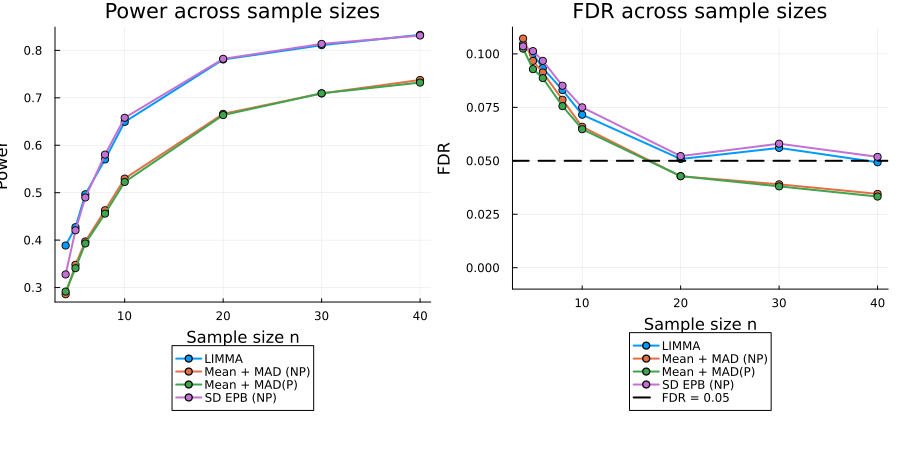

In [15]:
using Plots

# -------------------------------------------------
# 1. Build a common method dictionary
# -------------------------------------------------
method_summaries = Dict(
    "LIMMA" => limma_summary,
    "SD EPB (NP)" => epb_summary,
    "Mean + MAD (NP)" => mad_summary,
    "Mean + MAD(P)" => mad_param_gl_summary
)

# compute max FDR across all methods
max_fdr = maximum(vcat([summ["FDR"] for summ in values(method_summaries)]...))
fdr_upper = max(0.06, 1.05 * max_fdr)

# -------------------------------------------------
# 2. Power plot
# -------------------------------------------------
p_power = plot(
    xlabel = "Sample size n",
    ylabel = "Power",
    title = "Power across sample sizes",
    legend = :outerbottom,
    lw = 2,
    marker = :circle
)

for (method, summ) in method_summaries
    plot!(
        p_power,
        summ["n"],
        summ["Power"];
        label = method,
        lw = 2,
        marker = :circle
    )
end

# -------------------------------------------------
# 3. FDR plot
# -------------------------------------------------
p_fdr = plot(
    xlabel = "Sample size n",
    ylabel = "FDR",
    title = "FDR across sample sizes",
    legend = :outerbottom,
    lw = 2,
    marker = :circle,
    ylims = (-0.01, fdr_upper)
)

for (method, summ) in method_summaries
    plot!(
        p_fdr,
        summ["n"],
        summ["FDR"];
        label = method,
        lw = 2,
        marker = :circle
    )
end

hline!(
    p_fdr,
    [0.05];
    label = "FDR = 0.05",
    lw = 2,
    ls = :dash,
    color = :black
)

# -------------------------------------------------
# 4. Show side by side
# -------------------------------------------------
plot(
    p_power,
    p_fdr;
    layout = (1, 2),
    size = (900, 450)
)

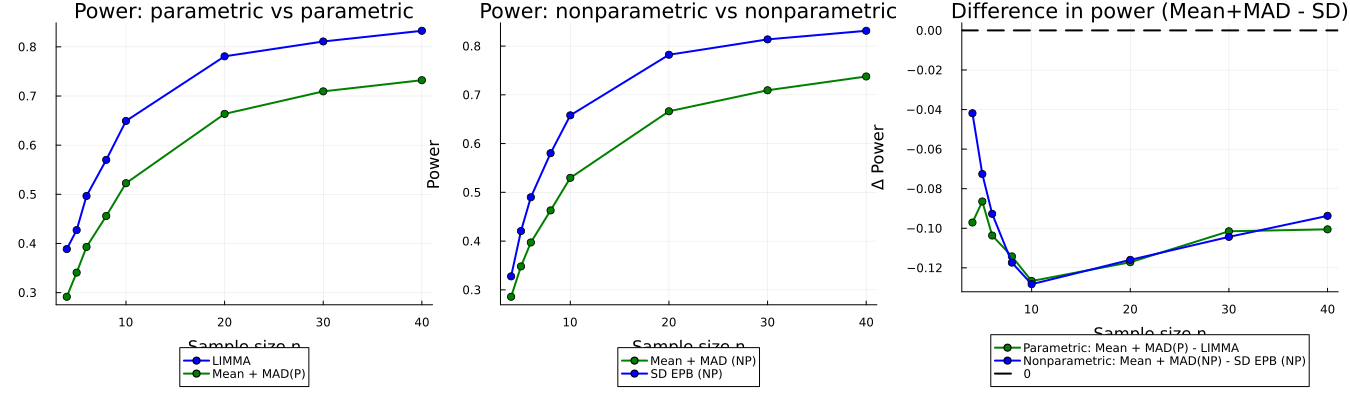

In [18]:
using Plots

# -------------------------------------------------
# 1. Split methods into two groups
# -------------------------------------------------
param_methods = Dict(
    "LIMMA" => limma_summary,
    "Mean + MAD(P)" => mad_param_gl_summary
)

nonparam_methods = Dict(
    "SD EPB (NP)" => epb_summary,
    "Mean + MAD (NP)" => mad_summary
)

# -------------------------------------------------
# 2. Shared colors
# -------------------------------------------------
method_colors = Dict(
    "LIMMA" => :blue,
    "SD EPB (NP)" => :blue,
    "Mean + MAD(P)" => :green,
    "Mean + MAD (NP)" => :green
)

# -------------------------------------------------
# 3. Power plot: parametric vs parametric
# -------------------------------------------------
p_power_param = plot(
    xlabel = "Sample size n",
    ylabel = "Power",
    title = "Power: parametric vs parametric",
    legend = :outerbottom,
    lw = 2,
    marker = :circle
)

for (method, summ) in param_methods
    plot!(
        p_power_param,
        summ["n"],
        summ["Power"];
        label = method,
        lw = 2,
        marker = :circle,
        color = method_colors[method]
    )
end

# -------------------------------------------------
# 4. Power plot: nonparametric vs nonparametric
# -------------------------------------------------
p_power_nonparam = plot(
    xlabel = "Sample size n",
    ylabel = "Power",
    title = "Power: nonparametric vs nonparametric",
    legend = :outerbottom,
    lw = 2,
    marker = :circle
)

for (method, summ) in nonparam_methods
    plot!(
        p_power_nonparam,
        summ["n"],
        summ["Power"];
        label = method,
        lw = 2,
        marker = :circle,
        color = method_colors[method]
    )
end

# -------------------------------------------------
# 5. Difference plot: Mean+MAD - SD
#    parametric: Mean+MAD(P) - LIMMA
#    nonparametric: Mean+MAD(NP) - SD EPB(NP)
# -------------------------------------------------
n_param = limma_summary["n"]
diff_param = mad_param_gl_summary["Power"] .- limma_summary["Power"]

n_nonparam = epb_summary["n"]
diff_nonparam = mad_summary["Power"] .- epb_summary["Power"]

p_diff = plot(
    xlabel = "Sample size n",
    ylabel = "Δ Power",
    title = "Difference in power (Mean+MAD - SD)",
    legend = :outerbottom,
    lw = 2,
    marker = :circle
)

plot!(
    p_diff,
    n_param,
    diff_param;
    label = "Parametric: Mean + MAD(P) - LIMMA",
    lw = 2,
    marker = :circle,
    color = :green
)

plot!(
    p_diff,
    n_nonparam,
    diff_nonparam;
    label = "Nonparametric: Mean + MAD(NP) - SD EPB (NP)",
    lw = 2,
    marker = :circle,
    color = :blue
)

hline!(
    p_diff,
    [0.0];
    label = "0",
    lw = 2,
    ls = :dash,
    color = :black
)

# -------------------------------------------------
# 6. Show all three
# -------------------------------------------------
plot(
    p_power_param,
    p_power_nonparam,
    p_diff;
    layout = (1, 3),
    size = (1350, 420)
)